# Exercise 12.1d solution

## Solving, plotting, and analyzing ionic currents


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
Cm = 1.0  # µF/cm²
E_Na = 50.0  # mV
E_K = -77.0  # mV
E_L = -54.4  # mV
gNa = 120.0  # mS/cm²
gK = 36.0  # mS/cm²
gL = 0.3  # mS/cm²
I_amp = 10.0  # µA/cm²


def rhs(t, y):
    V, m, h, n = y

    # Rate constants
    alpha_m = 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))
    beta_m = 4.0 * np.exp(-(V + 65.0) / 18.0)
    alpha_h = 0.07 * np.exp(-(V + 65.0) / 20.0)
    beta_h = 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))
    alpha_n = 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))
    beta_n = 0.125 * np.exp(-(V + 65.0) / 80.0)

    # Stimulus
    I_app = I_amp if (2 < t < 3) else 0.0

    # Ionic currents
    I_Na = gNa * m**3 * h * (V - E_Na)
    I_K = gK * n**4 * (V - E_K)
    I_L = gL * (V - E_L)

    # Derivatives
    dV_dt = (-I_Na - I_K - I_L + I_app) / Cm
    dm_dt = alpha_m * (1 - m) - beta_m * m
    dh_dt = alpha_h * (1 - h) - beta_h * h
    dn_dt = alpha_n * (1 - n) - beta_n * n

    return [dV_dt, dm_dt, dh_dt, dn_dt]


# ----------------------------------------------

In [2]:
# Initial conditions: [V, m, h, n]
# At rest (-65 mV), m and n are near 0, h is near 0.6
V0 = -65.0
y0 = [V0, 0.05, 0.6, 0.32]

# Solve
t_span = (0, 30)
t_eval = np.linspace(*t_span, 2000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval)

# Unpack
V, m, h, n = sol.y
t = sol.t

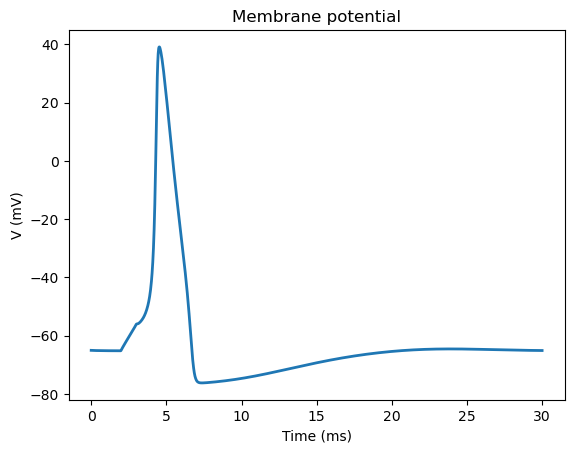

In [3]:
# 1. Plot the membrane potential
plt.plot(t, V, "C0", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.title("Membrane potential")
plt.show()

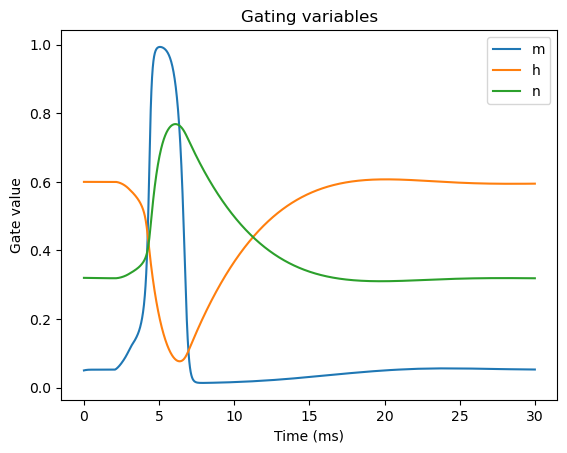

In [4]:
# 2. Plot gating variables
plt.plot(t, m, label="m")
plt.plot(t, h, label="h")
plt.plot(t, n, label="n")
plt.xlabel("Time (ms)")
plt.ylabel("Gate value")
plt.title("Gating variables")
plt.legend()
plt.show()

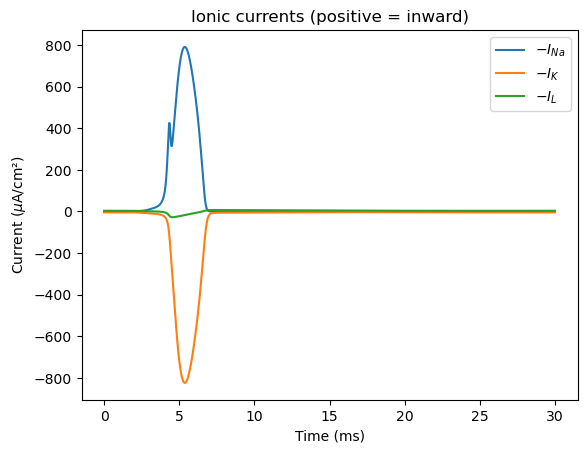

In [5]:
# 3. Plot ionic currents
I_Na = gNa * m**3 * h * (V - E_Na)
I_K = gK * n**4 * (V - E_K)
I_L = gL * (V - E_L)

plt.plot(sol.t, -I_Na, label=r"$-I_{Na}$")
plt.plot(sol.t, -I_K, label=r"$-I_K$")
plt.plot(sol.t, -I_L, label=r"$-I_L$")
plt.xlabel("Time (ms)")
plt.ylabel(r"Current ($\mu$A/cm²)")
plt.title("Ionic currents (positive = inward)")
plt.legend()
plt.show()

**Analysis:**

- **Depolarization:** Driven by $m$ (Na⁺ activation) — it rises fastest, allowing massive inward $I_{\mathrm{Na}}$.
- **Repolarization:** Caused by two mechanisms: (1) $h$ (Na⁺ inactivation) shuts off $I_{\mathrm{Na}}$, and (2) $n$ (K⁺ activation) opens $I_{\mathrm{K}}$ which pulls V back down.
- **Afterhyperpolarization:** The $n$ gates remain open after V has returned to rest, keeping $I_{\mathrm{K}}$ elevated and pushing V below the resting potential until $n$ slowly decays back to its resting value.
